### Importing Libraries

In [1]:
import os
import gc
import torch
import pandas as pd
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

In [2]:
pd.set_option('display.max_columns', None)

### Creating data manifest and splitting data

In [3]:
%cd ..

d:\Projects\BrainTumor-Classification-Segmentation


In [4]:
train_image = []
train_mask = []

root_dir = f'{os.getcwd()}/Data/segmentation_task/train'
image_dir = f'{root_dir}/images'
mask_dir = f'{root_dir}/masks'

for image in os.listdir(image_dir):
    mask = image.replace('.jpg', '.png')
    mask_path = f'{mask_dir}/{mask}'
    if os.path.exists(mask_path):
        train_image.append(f'{image_dir}/{image}')
        train_mask.append(mask_path)
    else:
        print(f"Mask doesn't exist for: {image}")

In [5]:
train = pd.DataFrame(zip(train_image, train_mask), columns = ['image', 'mask'])

In [6]:
test_image = []
test_mask = []

root_dir = f'{os.getcwd()}/Data/segmentation_task/test'
image_dir = f'{root_dir}/images'
mask_dir = f'{root_dir}/masks'

for image in os.listdir(image_dir):
    mask = image.replace('.jpg', '.png')
    mask_path = f'{mask_dir}/{mask}'
    if os.path.exists(mask_path):
        test_image.append(f'{image_dir}/{image}')
        test_mask.append(mask_path)
    else:
        print(f"Mask doesn't exist for: {image}")

In [7]:
test = pd.DataFrame(zip(test_image, test_mask), columns = ['image', 'mask'])

In [8]:
train, val = train_test_split(train, test_size = 0.3, random_state = 42, shuffle = True)
train = train.reset_index(drop = True)
val = val.reset_index(drop = True)

### Data Showcase

In [9]:
print(f'Train: \n{train.head()}')
print(f'Test: \n{test.head()}')
print(f'Validation: \n{val.head()}')

Train: 
                                               image  \
0  d:\Projects\BrainTumor-Classification-Segmenta...   
1  d:\Projects\BrainTumor-Classification-Segmenta...   
2  d:\Projects\BrainTumor-Classification-Segmenta...   
3  d:\Projects\BrainTumor-Classification-Segmenta...   
4  d:\Projects\BrainTumor-Classification-Segmenta...   

                                                mask  
0  d:\Projects\BrainTumor-Classification-Segmenta...  
1  d:\Projects\BrainTumor-Classification-Segmenta...  
2  d:\Projects\BrainTumor-Classification-Segmenta...  
3  d:\Projects\BrainTumor-Classification-Segmenta...  
4  d:\Projects\BrainTumor-Classification-Segmenta...  
Test: 
                                               image  \
0  d:\Projects\BrainTumor-Classification-Segmenta...   
1  d:\Projects\BrainTumor-Classification-Segmenta...   
2  d:\Projects\BrainTumor-Classification-Segmenta...   
3  d:\Projects\BrainTumor-Classification-Segmenta...   
4  d:\Projects\BrainTumor-Classificati

### Dataset and DataLoader

In [10]:
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

d:\Projects\BrainTumor-Classification-Segmentation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
train_transform = A.Compose([
    A.Resize(512, 512),
    A.HorizontalFlip(),
    A.VerticalFlip(),
    A.ShiftScaleRotate(shift_limit = 0.0625, scale_limit = 0.1, rotate_limit = 15, p = 0.5),
    A.GridDistortion(p = 0.5),
    A.RandomBrightnessContrast(p = 0.2),
    A.Normalize(mean = (0.485, 0.456, 0.406), std = (0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean = (0.485, 0.456, 0.406), std = (0.229, 0.224, 0.225)),
    ToTensorV2()
])

d:\Projects\BrainTumor-Classification-Segmentation\.venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [12]:
class CustomData(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
       row = self.dataframe.iloc[index]

       image = np.array(Image.open(row['image']).convert('RGB'))
       mask_pil = Image.open(row['mask']).convert('L')
       mask_array = (np.array(mask_pil) > 0).astype(np.float32)

       if self.transform:
           augmented = self.transform(image = image, mask = mask_array)
           image = augmented['image']
           mask = augmented['mask'].unsqueeze(0)

       return image, mask  

In [13]:
train = CustomData(train, train_transform)
test = CustomData(test, val_transform)
val = CustomData(val, val_transform)

In [14]:
train_loader = DataLoader(train, batch_size = 6, shuffle = True, pin_memory = True)
test_loader = DataLoader(test, batch_size = 6, shuffle = False, pin_memory = True)
val_loader = DataLoader(val, batch_size = 6, shuffle = False, pin_memory = True)

### Model initialization

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [16]:
import segmentation_models_pytorch as smp

In [17]:
model = smp.UnetPlusPlus(
    encoder_name = 'resnet50',
    encoder_weights = 'imagenet',
    in_channels = 3,
    classes = 1,
    activation = None
)
model = model.to(device)

In [18]:
print(model.encoder)

ResNetEncoder(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (

In [19]:
for param in model.encoder.parameters():
    param.requires_grad = True

### Training

In [20]:
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [21]:
optimizer = Adam([
    {'params': model.encoder.parameters(), 'lr': 1e-5},
    {'params': model.decoder.parameters(), 'lr': 1e-3},
    {'params': model.segmentation_head.parameters(), 'lr': 1e-3}
])

criterion_bce = nn.BCEWithLogitsLoss()
criterion_tvl = smp.losses.TverskyLoss(mode = 'binary', alpha = 0.3, beta = 0.85)

In [22]:
def dice_coefficient(pred, target, epsilon = 1e-6, threshold = 0.5):
    pred = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred * target).sum(dim = (1, 2, 3))
    union = pred.sum(dim = (1, 2, 3)) + target.sum(dim = (1, 2, 3))
    dice = (2 * intersection + epsilon) / (union + epsilon)
    return dice.mean().item()

def IoU(pred, target, epsilon = 1e-6, threshold = 0.5):
    pred = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred * target).sum(dim = (1, 2, 3))
    union = pred.sum(dim = (1, 2, 3)) + target.sum(dim = (1, 2, 3)) - intersection
    iou = (intersection + epsilon) / (union + epsilon)
    return iou.mean().item()

def combined_loss(pred, true):
    return criterion_bce(pred, true) + criterion_tvl(pred, true)

In [23]:
epochs = 20
early_stopping = 5
best_val_dice = 0.0
counter = 0

scaler = torch.amp.GradScaler('cuda')
scheduler = ReduceLROnPlateau(optimizer, mode = 'max', factor = 0.5, patience = 3)

for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    
    for image, mask in train_loader:
        image, mask = image.to(device), mask.to(device).float()

        # YOU MUST ZERO THE GRADIENTS HERE
        optimizer.zero_grad()

        with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
            output = model(image)
            loss = combined_loss(output, mask)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    model.eval()
    val_dice_scores = []
    
    with torch.no_grad():
        for image, mask in val_loader:
            image, mask = image.to(device), mask.to(device).float()

            with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                output = model(image)
                
            dice = dice_coefficient(output, mask)
            val_dice_scores.append(dice)

    avg_val_dice = sum(val_dice_scores) / len(val_dice_scores)
    print(f'Epoch: {epoch} | Loss: {total_loss / len(train_loader):.4f} | Validation Dice = {avg_val_dice:.4f}')
    scheduler.step(avg_val_dice)

    if avg_val_dice > best_val_dice:
        best_val_dice = avg_val_dice
        counter = 0
        torch.save(model.state_dict(), 'artifacts/objects/segmentation.pth')
        print(f'Model with score: {best_val_dice:.4f} saved')
    else:
        counter += 1
        if counter >= early_stopping:
            print(f'No improvement found at epoch {epoch}. Early stopping triggered.')
            break

gc.collect()
torch.cuda.empty_cache()

Epoch: 0 | Loss: 0.5139 | Validation Dice = 0.7212
Model with score: 0.7212 saved
Epoch: 1 | Loss: 0.2900 | Validation Dice = 0.7442
Model with score: 0.7442 saved
Epoch: 2 | Loss: 0.2520 | Validation Dice = 0.7474
Model with score: 0.7474 saved
Epoch: 3 | Loss: 0.2331 | Validation Dice = 0.7624
Model with score: 0.7624 saved
Epoch: 4 | Loss: 0.2190 | Validation Dice = 0.7701
Model with score: 0.7701 saved
Epoch: 5 | Loss: 0.2109 | Validation Dice = 0.7801
Model with score: 0.7801 saved
Epoch: 6 | Loss: 0.2069 | Validation Dice = 0.7880
Model with score: 0.7880 saved
Epoch: 7 | Loss: 0.2028 | Validation Dice = 0.7868
Epoch: 8 | Loss: 0.1943 | Validation Dice = 0.7988
Model with score: 0.7988 saved
Epoch: 9 | Loss: 0.1855 | Validation Dice = 0.7975
Epoch: 10 | Loss: 0.1856 | Validation Dice = 0.7895
Epoch: 11 | Loss: 0.1793 | Validation Dice = 0.8025
Model with score: 0.8025 saved
Epoch: 12 | Loss: 0.1766 | Validation Dice = 0.8019
Epoch: 13 | Loss: 0.1753 | Validation Dice = 0.8028
Mod

### Evaluation

In [24]:
model.load_state_dict(torch.load('artifacts/objects/segmentation.pth', map_location=device))
model.eval()

print("Scanning for optimal threshold...")

thresholds = np.arange(0.1, 0.95, 0.05)

intersections = {th: 0.0 for th in thresholds}
unions = {th: 0.0 for th in thresholds}

with torch.no_grad():
    for image, mask in val_loader:
        image, mask = image.to(device), mask.to(device).float()
        
        # Forward pass
        with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
            logits = model(image)
            
        probs = torch.sigmoid(logits)
        
        for th in thresholds:
            pred_mask = (probs > th).float()
            
            intersections[th] += (pred_mask * mask).sum().item()
            unions[th] += (pred_mask.sum() + mask.sum()).item()

best_threshold = 0.5
best_dice = 0.0

for th in thresholds:
    # Dice Formula: 2 * Intersection / Union
    dice = (2 * intersections[th] + 1e-6) / (unions[th] + 1e-6)
    print(f"Threshold: {th:.2f} -> Val Dice: {dice:.4f}")
    
    if dice > best_dice:
        best_dice = dice
        best_threshold = th

print(f"\n[SUCCESS] Optimal Threshold is {best_threshold:.2f} with Dice: {best_dice:.4f}")

Scanning for optimal threshold...
Threshold: 0.10 -> Val Dice: 0.8366
Threshold: 0.15 -> Val Dice: 0.8390
Threshold: 0.20 -> Val Dice: 0.8407
Threshold: 0.25 -> Val Dice: 0.8420
Threshold: 0.30 -> Val Dice: 0.8431
Threshold: 0.35 -> Val Dice: 0.8441
Threshold: 0.40 -> Val Dice: 0.8449
Threshold: 0.45 -> Val Dice: 0.8458
Threshold: 0.50 -> Val Dice: 0.8466
Threshold: 0.55 -> Val Dice: 0.8474
Threshold: 0.60 -> Val Dice: 0.8482
Threshold: 0.65 -> Val Dice: 0.8490
Threshold: 0.70 -> Val Dice: 0.8500
Threshold: 0.75 -> Val Dice: 0.8509
Threshold: 0.80 -> Val Dice: 0.8521
Threshold: 0.85 -> Val Dice: 0.8535
Threshold: 0.90 -> Val Dice: 0.8555

[SUCCESS] Optimal Threshold is 0.90 with Dice: 0.8555


In [25]:
model.load_state_dict(torch.load('artifacts/objects/segmentation.pth', map_location = device))
model = model.to(device)
model.eval()
test_dice_scores = []
test_IoU_scores = []

with torch.no_grad():
    for image, mask in test_loader:
        image, mask = image.to(device), mask.to(device).float()

        output = model(image)
        dice = dice_coefficient(output, mask, threshold = best_threshold)
        iou = IoU(output, mask, threshold = best_threshold)

        test_dice_scores.append(dice)
        test_IoU_scores.append(iou)

print(f'Test Dice: {sum(test_dice_scores) / len(test_dice_scores):.4f}')
print(f'Test IoU: {sum(test_IoU_scores) / len(test_IoU_scores):.4f}')       

gc.collect()
torch.cuda.empty_cache()

Test Dice: 0.8212
Test IoU: 0.7289


In [26]:
from scipy import ndimage

def component_recall(pred, target, threshold=0.5, min_size=10):
    pred_binary = (torch.sigmoid(pred) > threshold).float().cpu().numpy()
    target_np = target.cpu().numpy()

    detected, total = 0, 0
    for i in range(target_np.shape[0]):
        labeled_gt, num_components = ndimage.label(target_np[i, 0])
        for comp_id in range(1, num_components + 1):
            component_mask = (labeled_gt == comp_id)
            if component_mask.sum() < min_size:
                continue  # skip noise specks, not real structures
            total += 1
            if (pred_binary[i, 0] * component_mask).sum() > 0:
                detected += 1
    return detected, total


model.load_state_dict(torch.load('artifacts/objects/segmentation.pth', map_location=device))
model.eval()

total_detected = 0
total_components = 0

with torch.no_grad():
    for image, mask in test_loader:
        image, mask = image.to(device), mask.to(device).float()

        with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
            output = model(image)

        detected, total = component_recall(output, mask, threshold=best_threshold)
        total_detected += detected
        total_components += total

component_recall_score = total_detected / total_components
print(f'Component-level recall: {component_recall_score:.4f} ({total_detected}/{total_components} regions detected)')

Component-level recall: 0.4132 (1575/3812 regions detected)


### Visualization

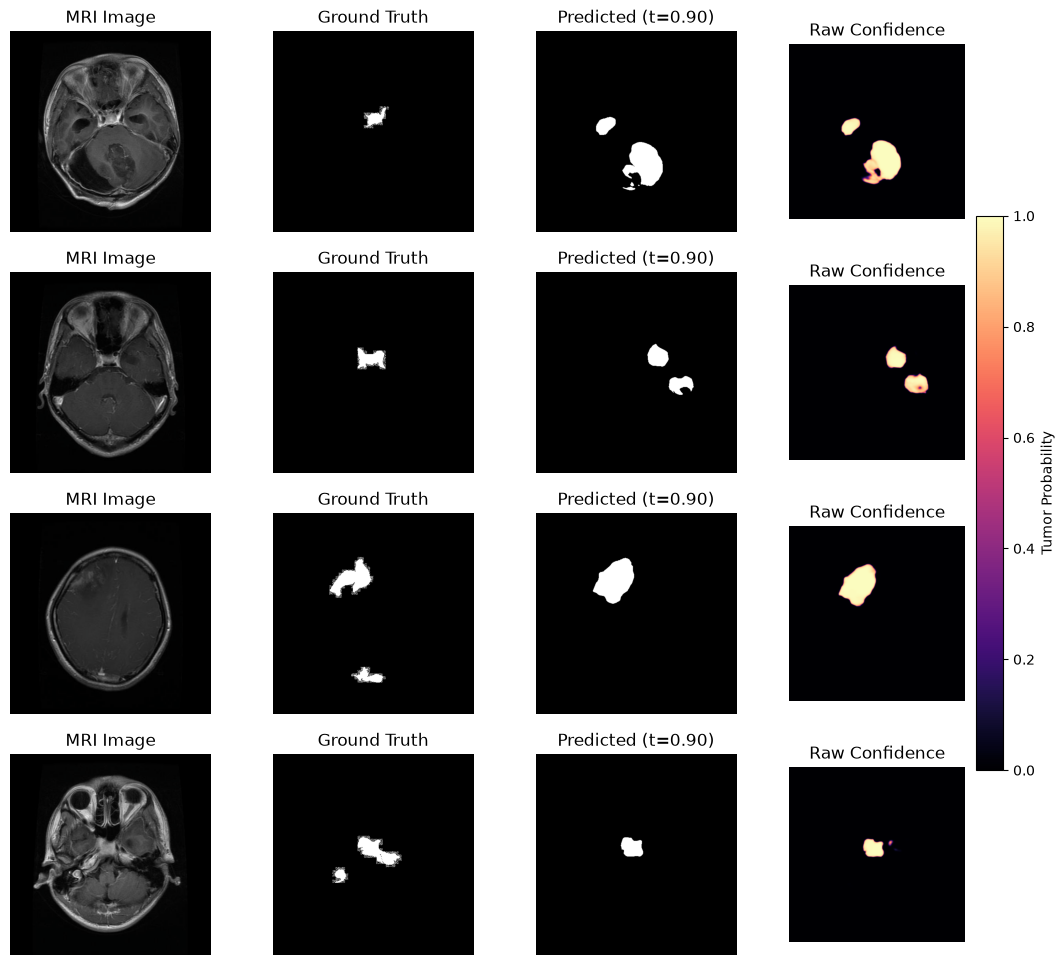

In [27]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    image, mask = next(iter(test_loader))
    image, mask = image.to(device), mask.to(device).float()

    with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
        output = model(image)

    raw_probs = torch.sigmoid(output)
    pred_mask = (raw_probs > best_threshold).float()

n = 4
fig, axes = plt.subplots(n, 4, figsize=(13, 3*n))

im = None
for i in range(n):
    img_np = image[i].cpu().permute(1,2,0).numpy()
    img_np = img_np * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    img_np = img_np.clip(0, 1)

    axes[i,0].imshow(img_np)
    axes[i,0].set_title('MRI Image')

    axes[i,1].imshow(mask[i,0].cpu(), cmap='gray')
    axes[i,1].set_title('Ground Truth')

    axes[i,2].imshow(pred_mask[i,0].cpu(), cmap='gray')
    axes[i,2].set_title(f'Predicted (t={best_threshold:.2f})')

    prob_map = raw_probs[i, 0].cpu().numpy()
    im = axes[i,3].imshow(prob_map, cmap='magma', vmin=0, vmax=1)
    axes[i,3].set_title('Raw Confidence')

    for ax in axes[i]:
        ax.axis('off')

fig.colorbar(im, ax=axes[:, 3].tolist(), shrink=0.6, label='Tumor Probability')
plt.show()

In [28]:
gc.collect()
torch.cuda.empty_cache()